## Correlation Coefficient:
If two features are highly correlated:
- They carry similar information
- Keeping both is redundant

Example:
- Square feet
- Number of tiles (almost proportional)
We can remove one.

When to Use
- Numerical features
- Detect multicollinearity

In [2]:
import pandas as pd
import numpy as np

data = pd.DataFrame({
    'size_sqrt': [1000, 1500, 2000, 2500, 3000],
    'titles_count': [100, 150, 200, 250, 300],
    'price': [200000, 300000, 400000, 500000, 600000]
})

data

,size_sqrt,titles_count,price
0,1000,100,200000
1,1500,150,300000
2,2000,200,400000
3,2500,250,500000
4,3000,300,600000


In [3]:
correlation_matrix = data.corr()
print(correlation_matrix)

              size_sqrt  titles_count  price
size_sqrt           1.0           1.0    1.0
titles_count        1.0           1.0    1.0
price               1.0           1.0    1.0


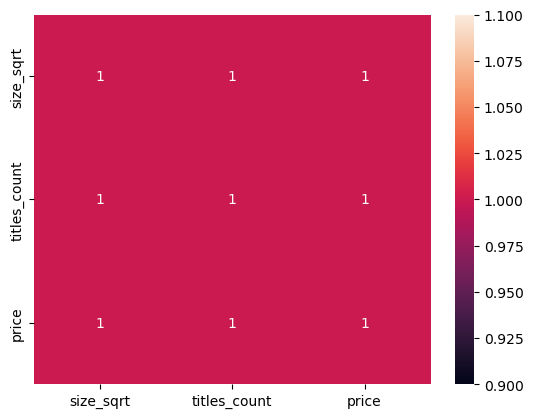

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(correlation_matrix, annot = True)
plt.show()

In [5]:
# Removing highly Correlated Features (>0.9)

upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k = 1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column]>0.9)]

print('Highly Corrleated Features to Drop:', to_drop)

Highly Corrleated Features to Drop: ['titles_count', 'price']


## 🏠 Scenario: Real Estate Price Prediction
You are developing a regression model to predict house prices.

- Dataset contains:
    - House Size (sqft)
    - Number of Tiles
    - Total Construction Cost
    - Number of Bedrooms
    - Market Price

- After calculating correlation matrix, you find:
    - House Size and Number of Tiles have 0.98 - correlation
    - Construction Cost is highly correlated (0.95) with - House Size

- ❓ Question:
    1.  Why is high correlation between features a1.    roblem?
    2.  Which feature(s) would you remove and why?
    3.  What issue can occur if highly correlated1.     eatures are  - kept?
    4.  Which filter method is appropriate here?

In [6]:
import pandas as pd
import numpy as np

from statsmodels.stats.outliers_influence import variance_inflation_factor


In [8]:
data = {
    "House_Size": [1200, 1500, 1800, 2000, 2200],
    "Number_of_Tiles": [300, 380, 460, 520, 560],
    "Construction_Cost": [30, 38, 45, 52, 58],
    "Bedrooms": [2, 3, 3, 4, 4],
    "Market_Price": [50, 65, 78, 90, 100]
}

df = pd.DataFrame(data)

data


{'House_Size': [1200, 1500, 1800, 2000, 2200],
 'Number_of_Tiles': [300, 380, 460, 520, 560],
 'Construction_Cost': [30, 38, 45, 52, 58],
 'Bedrooms': [2, 3, 3, 4, 4],
 'Market_Price': [50, 65, 78, 90, 100]}

In [11]:
corr_matrix = df.corr()
print("Correlation Matrix:\n", corr_matrix)

Correlation Matrix:
                    House_Size  Number_of_Tiles  Construction_Cost  Bedrooms  \
House_Size           1.000000         0.999028           0.997772  0.947181   
Number_of_Tiles      0.999028         1.000000           0.996178  0.953807   
Construction_Cost    0.997772         0.996178           1.000000  0.954542   
Bedrooms             0.947181         0.953807           0.954542  1.000000   
Market_Price         0.998988         0.997988           0.999651  0.955860   

                   Market_Price  
House_Size             0.998988  
Number_of_Tiles        0.997988  
Construction_Cost      0.999651  
Bedrooms               0.955860  
Market_Price           1.000000  


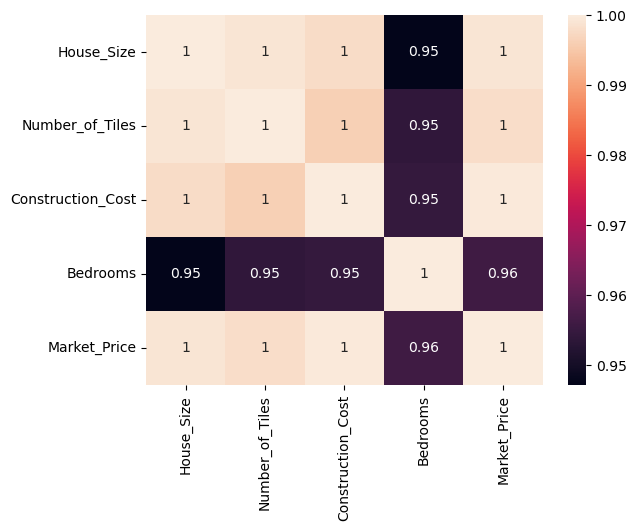

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(corr_matrix, annot = True)
plt.show()

In [14]:
# Removing highly Correlated Features (>0.9)

upper1 = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool)
)

to_drop1 = [column for column in upper1.columns if any(upper1[column]>0.9)]

print('Highly Corrleated Features to Drop:', to_drop1)

Highly Corrleated Features to Drop: ['Number_of_Tiles', 'Construction_Cost', 'Bedrooms', 'Market_Price']
